In [33]:
import os
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from photutils.utils import ShepardIDWInterpolator
from scipy.spatial import KDTree
import matplotlib.patches as mpatch
import rasterio as rio
import rasterio.transform as rio_transform

In [19]:
data_path = Path(os.environ["DATA_PATH"])

In [20]:
bounds = gpd.read_file(data_path / "lim_aumxl24").to_crs("EPSG:6372")["geometry"].item()

In [21]:
df = gpd.GeoDataFrame(
    pd.read_excel(data_path / "calidad_del_aire.xlsx", sheet_name=1)
    .assign(
        geometry=lambda df: gpd.points_from_xy(df["lng"], df["lat"]),
        date=lambda df: pd.to_datetime(
            df["Año"].astype(str) + "-" + df["Mes"].astype(str) + "-01",
            format="%Y-%m-%d",
        ),
    )
    .rename(columns={"µg/m³": "mug/m3"})
    .drop(columns=["lng", "lat", "Año", "Mes"]),
    crs="EPSG:4326",
    geometry="geometry",
).to_crs("EPSG:6372")

df = df[df.within(bounds)]

In [45]:
xmin, ymin, xmax, ymax = df.total_bounds

offset = 2000
xmin -= offset
xmax += offset
ymin -= offset
ymax += offset

xrange = np.arange(xmin, xmax, 50)
yrange = np.arange(ymin, ymax, 50)

xx, yy = np.meshgrid(xrange, yrange)

In [46]:
year = 2024

df_seasonal = []
for start_month, end_month, season in [
    (1, 3, "winter"),
    (4, 6, "spring"),
    (7, 9, "summer"),
    (10, 12, "fall"),
]:
    temp = gpd.GeoDataFrame(
        df.query(
            f"'{year}-{str(start_month).zfill(2)}-01' <= date <= '{year}-{str(end_month).zfill(2)}-30'",
        )
        .groupby("idmonitor")
        .agg({"geometry": "first", "mug/m3": "mean"}),
        crs=df.crs,
        geometry="geometry",
    )
    temp = temp.assign(season=season)
    df_seasonal.append(temp)

df_seasonal = pd.concat(df_seasonal).reset_index().set_index(["season", "idmonitor"])

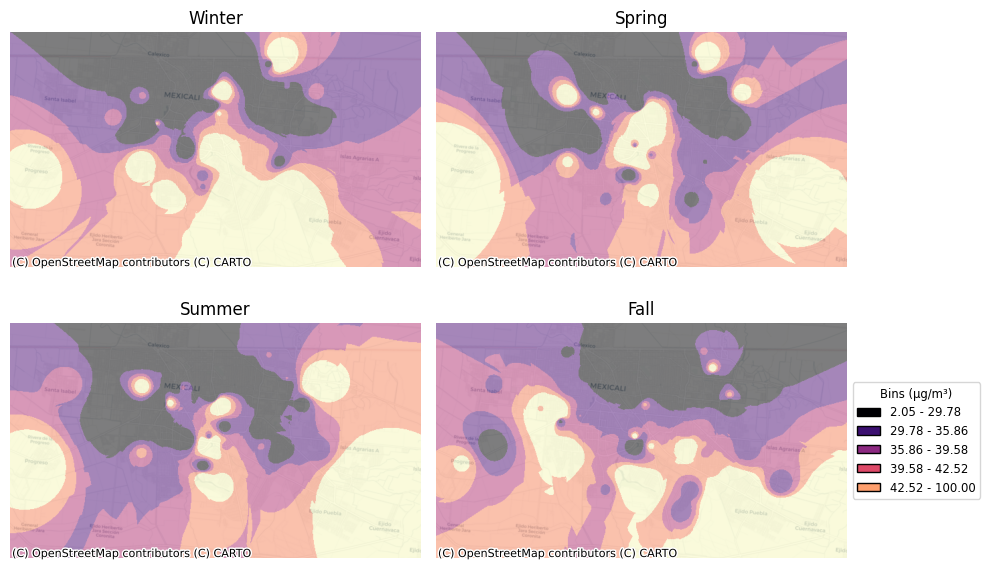

In [47]:
num_bins = 6

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

final_arr = []

for season, ax in zip(["winter", "spring", "summer", "fall"], axes.flatten()):
    temp = df_seasonal.loc[season]
    coords = temp.get_coordinates().to_numpy()
    values = temp["mug/m3"].to_numpy()

    interp = ShepardIDWInterpolator(coords, values)
    res = interp(
        np.vstack([xx.flatten(), yy.flatten()]).T,
        n_neighbors=15,
        power=2,
    ).reshape(xx.shape)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    cx.add_basemap(ax=ax, crs=df.crs, source=cx.providers.CartoDB.Positron)

    bins = np.quantile(res, q=np.linspace(0, 1, num_bins))
    digitized = np.digitize(
        res,
        bins=bins,
    )
    digitized[digitized == num_bins] = num_bins - 1

    final_arr.append(digitized)

    im = ax.imshow(
        digitized,
        cmap="magma",
        extent=(xmin, xmax, ymin, ymax),
        alpha=0.5,
        origin="lower",
    )
    ax.axis("off")
    ax.set_title(season.title())

final_arr = np.array(final_arr)

# Create legend outside the axes
bin_labels = [f"{bins[i]:.2f} - {bins[i+1]:.2f}" for i in range(len(bins)-1)]
colors = [plt.cm.magma(i/(num_bins-1)) for i in range(num_bins-1)]
legend_handles = [mpatch.Patch(facecolor=colors[i], edgecolor='k', label=bin_labels[i]) for i in range(num_bins-1)]
ax.legend(handles=legend_handles, title="Bins (µg/m³)", loc="center left", bbox_to_anchor=(1, 0.5), fontsize="small", title_fontsize="small", frameon=True)

fig.tight_layout()

In [48]:
transform

Affine(99.87576063943372, 0.0, 1215235.6901713219,
       0.0, -99.85717485023567, 2350731.723303302)

In [49]:
transform = rio_transform.from_bounds(
    xmin,
    ymin,
    xmax,
    ymax,
    width=final_arr.shape[2],
    height=final_arr.shape[1],
)

with rio.open(
    "./air_quality.tif",
    "w",
    count=final_arr.shape[0],
    height=final_arr.shape[1],
    width=final_arr.shape[2],
    dtype="uint8",
    crs=df.crs,
    transform=transform,
    compress="lzw",
    nodata=None
) as dst:
    dst.write(final_arr.astype(np.uint8))

In [260]:
np.unique(digitized, return_counts=True)

(array([1, 2, 3, 4, 5]), array([10807, 10806, 10806, 10806, 10807]))